###Section 1: Install Required Libraries and Import Dependencies###

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

**Section 2: Data Collection and Cleaning**

In [3]:
# Step 1: Data Collection and Cleaning
def download_data(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date)
    data.dropna(inplace=True)
    return data

**Section 3: Technical Indicators**

In [4]:
# Custom implementation of RSI
def calculate_rsi(data, window=14):
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    data['RSI'] = rsi
    return data

# Custom implementation of MACD
def calculate_macd(data):
    ema_12 = data['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = data['Close'].ewm(span=26, adjust=False).mean()
    macd = ema_12 - ema_26
    signal = macd.ewm(span=9, adjust=False).mean()
    data['MACD'] = macd - signal
    return data

# Adding technical indicators
def add_technical_indicators(data):
    data['MA_20'] = data['Close'].rolling(window=20).mean()
    data = calculate_rsi(data)
    data = calculate_macd(data)
    data.dropna(inplace=True)
    return data

**Section 4: Feature Engineering**

In [5]:
def create_features_and_labels(data):
    data['Target'] = np.where(data['Close'].shift(-1) > data['Close'], 1, 0)  # 1 if price increases
    X = data[['MA_20', 'RSI', 'MACD']]
    y = data['Target']
    return X, y

**Section 5: Model Training**

In [6]:
# Training a Random Forest Classifier
def train_random_forest(X_train, y_train):
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    return model

**Section 6: Model Evaluation**

In [7]:
# Evaluating the model
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    return accuracy, conf_matrix, y_pred

**Section 7: Strategy Simulation**

In [13]:
# Simulate the strategy's performance
def simulate_strategy(data, y_pred):
    simulated_data = data.iloc[len(data) - len(y_pred):].copy()
    simulated_data['Strategy'] = y_pred
    simulated_data['Market_Return'] = np.log(simulated_data['Close'] / simulated_data['Close'].shift(1))
    simulated_data['Strategy_Return'] = simulated_data['Market_Return'] * simulated_data['Strategy'].shift(1)
    simulated_data.dropna(inplace=True)
    return simulated_data

# Plot the results
def plot_results(data):
    # Create a cumulative sum of returns for both the market and strategy
    market_cum_return = data['Market_Return'].cumsum()
    strategy_cum_return = data['Strategy_Return'].cumsum()

    plt.figure(figsize=(14, 8))

    # Plot Market Performance
    plt.plot(data.index, market_cum_return, label='Market Cumulative Return', linewidth=2)

    # Plot Strategy Performance
    plt.plot(data.index, strategy_cum_return, label='Strategy Cumulative Return', linewidth=2, linestyle='--')

    # Highlight areas of underperformance/overperformance
    plt.fill_between(data.index, market_cum_return, strategy_cum_return,
                     where=(strategy_cum_return > market_cum_return),
                     color='green', alpha=0.1, label='Outperformance')
    plt.fill_between(data.index, market_cum_return, strategy_cum_return,
                     where=(strategy_cum_return <= market_cum_return),
                     color='red', alpha=0.1, label='Underperformance')

    # Add labels, grid, and legend
    plt.title('Trading Strategy vs Market Performance', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Cumulative Return', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.5)

    # Show the final plot
    plt.tight_layout()
    plt.show()

**Section 8: Main Function**

In [11]:
def main():
    # Parameters
    ticker = '^GSPC'  # S&P 500 index
    start_date = '2014-01-01'
    end_date = '2024-12-01'

    # Download and preprocess data
    data = download_data(ticker, start_date, end_date)
    data = add_technical_indicators(data)
    X, y = create_features_and_labels(data)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train model
    model = train_random_forest(X_train, y_train)

    # Evaluate model
    accuracy, conf_matrix, y_pred = evaluate_model(model, X_test, y_test)
    print(f"Model Accuracy: {accuracy}")
    print("Confusion Matrix:")
    print(conf_matrix)

    # Simulate strategy
    simulated_data = simulate_strategy(data, y_pred)
    plot_results(simulated_data)

**Section 9: Execute Main**

[*********************100%***********************]  1 of 1 completed


Model Accuracy: 0.48534798534798534
Confusion Matrix:
[[103 164]
 [117 162]]


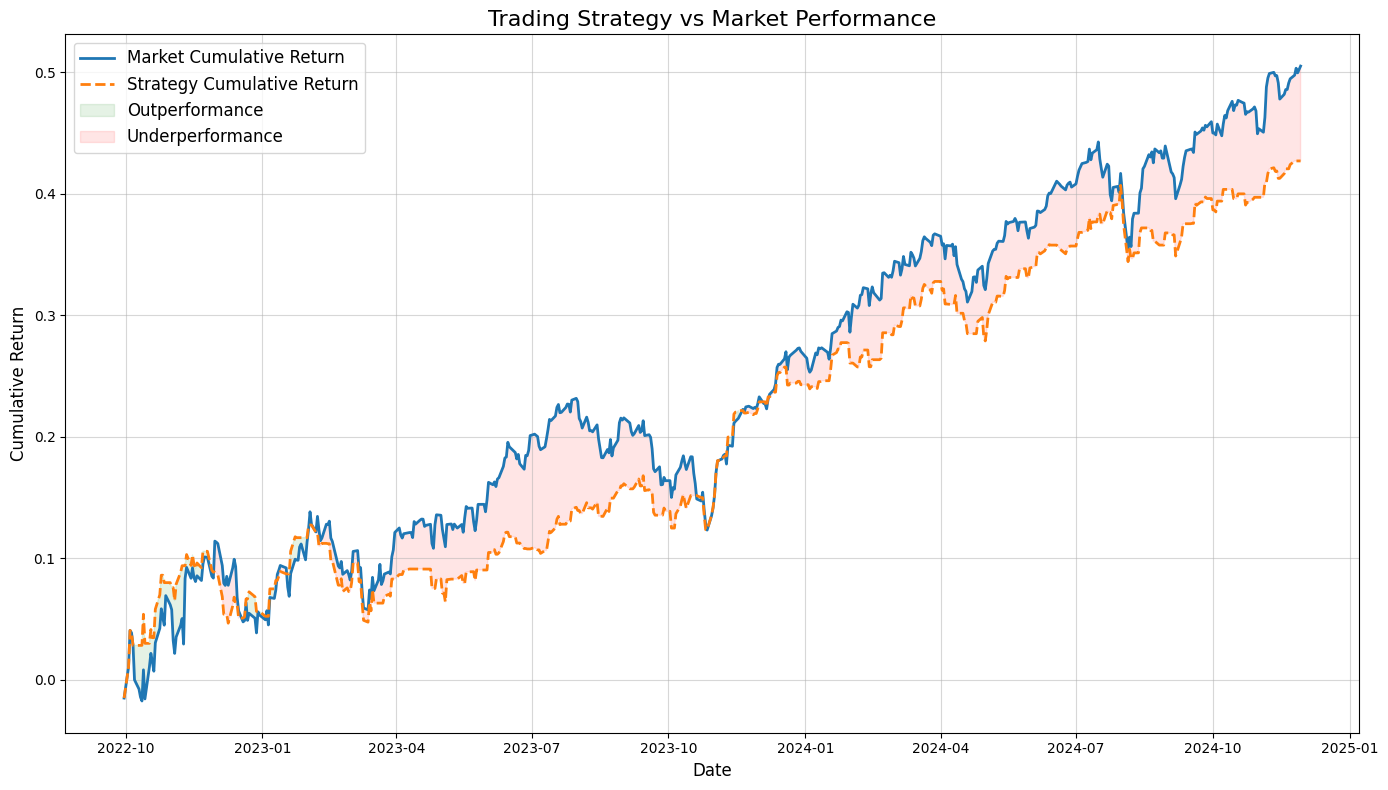

In [14]:
if __name__ == "__main__":
    main()